# Data Overview & Preparation

The dataset contains **4.1M search impressions** from a single day, representing individual product placements within search results. Each row is a product shown to a user for a given keyword query, along with behavioral outcomes (view, click, conversion).

**Session construction:** user_id × keyword alone does not uniquely identify a search session. the same user can search the same keyword multiple times in a day. We detect session boundaries by identifying where the result index resets (drops instead of increasing monotonically), yielding **263,602 unique query sessions**.

**Language landscape:** ~40% of search queries are in Arabic, while the product catalog (designer names, product descriptions) is 95% Latin-script. This mismatch is a structural constraint on keyword-based search because arabic queries must match against English-indexed product attributes.

**Catalog completeness:** ~5% of product impressions are missing all metadata (name, designer, class, productclass). These products have zero conversions despite being surfaced in search results, they consume search space unnecesarily.

**Key finding:** Arabic and Latin queries produce nearly identical click-through rates (~2%), but Latin queries convert at **2.4× the rate** of Arabic queries (0.16% vs. 0.07%). This suggests Arabic search retrieves plausibly related products (users click to investigate) but fails at relevance (users don't buy). This means there is an opportunity to workon precision.


In [ ]:
import pandas as pd
search_df = pd.read_parquet("../../data/raw_data/search_dataset.parquet")

In [24]:
search_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4113891 entries, 0 to 4113890
Data columns (total 18 columns):
 #   Column            Dtype         
---  ------            -----         
 0   dt                object        
 1   ts                datetime64[ns]
 2   user_id           str           
 3   app_country       str           
 4   keyword           str           
 5   index             int64         
 6   product_id        str           
 7   productclass      str           
 8   class             str           
 9   designer          str           
 10  name              str           
 11  plp_view          int64         
 12  plp_click         int64         
 13  is_converted      int64         
 14  keyword_type      str           
 15  keyword_lang      str           
 16  designer_lang     str           
 17  description_lang  str           
dtypes: datetime64[ns](1), int64(4), object(1), str(12)
memory usage: 1.4+ GB


In [ ]:
#  user_id and keyword aren't enough to identify a query session
#  we utilize the index for a particular user_id x keyword pair to identify a cutoff point
#  that point allows us to use a query_id label that we can group by later on to identify and analyze unique query sessions
#  noting that a user_id x keyword pair can occur multiple times across different sessions (assumption: a user can run the same query multiple times) 
#  role of using ts here is to enable the split logic. For example, a user can query "Dior" at 10 AM and then later at 2 PM. The results should not be mixed, hence why we include it in the group by.
#  
search_df = search_df.sort_values(["user_id", "keyword", "ts", "index"])
search_df["index_reset"] = search_df.groupby(["user_id", "keyword"])["index"].diff() <= 0
search_df["index_reset"] = search_df["index_reset"].fillna(True)  # first row of each group starts a session
search_df["query_id"] = search_df.groupby(["user_id", "keyword"])["index_reset"].cumsum()

"""
In other words: within each user-keyword pair, monotonically increasing index values belong to the same search event, 
and any index that drops signals a new one.  The query_id counter labels which search event each row belongs to.
"""


In [27]:
# Validation: user_id x keyword x query_id x index should be unique (1 product per position per session)
assert search_df.groupby(["user_id", "keyword", "query_id", "index"]).size().max() == 1


In [28]:
query_signature_final_cols = ["user_id", "keyword", "query_id"]

In [34]:
import regex as re

"We'll use a simple approach to detecting arabic/latin in our catalog columns"
"This is key to determining if clicks/impressions/conversions vary across language"

def detect_script(text):
    if pd.isna(text):
        return 'unknown'
    
    text = str(text)
    has_arabic = bool(re.search(r'\p{Arabic}', text))
    has_latin = bool(re.search(r'\p{Latin}', text))
    
    if has_arabic and has_latin:
        return 'mixed'
    elif has_arabic:
        return 'arabic'
    elif has_latin:
        return 'latin'
    else:
        return 'other'

search_df['keyword_lang'] = search_df['keyword'].apply(detect_script)
search_df["designer_lang"] = search_df['designer'].apply(detect_script)
search_df["description_lang"] = search_df['name'].apply(detect_script)

In [ ]:
# Almost ~40% of keyword searches are in arabic
keyword_lang_dist = search_df['keyword_lang'].value_counts(normalize=True) * 100
print(keyword_lang_dist)


keyword_lang
latin      60.259229
arabic     39.672855
mixed       0.034469
other       0.032573
unknown     0.000875
Name: proportion, dtype: float64


In [36]:
description_lang_dist = search_df['description_lang'].value_counts(normalize=True) * 100
print(description_lang_dist)


description_lang
latin      95.029839
unknown     4.948332
mixed       0.021828
Name: proportion, dtype: float64


In [37]:
description_lang_dist = search_df['description_lang'].value_counts(normalize=True) * 100
print(description_lang_dist)


description_lang
latin      95.029839
unknown     4.948332
mixed       0.021828
Name: proportion, dtype: float64


In [38]:
keyword_lang_analysis = search_df.groupby('keyword_lang').agg({
    'plp_click': ['count', 'sum', 'mean'],  
    'is_converted': 'mean'  #
})
print(keyword_lang_analysis)

             plp_click                  is_converted
                 count    sum      mean         mean
keyword_lang                                        
arabic         1632098  32900  0.020158     0.000664
latin          2478999  49578  0.019999     0.001574
mixed             1418     39  0.027504     0.002116
other             1340     70  0.052239     0.011194
unknown             36      2  0.055556     0.000000


In [47]:
float(keyword_lang_analysis["is_converted"]["mean"]["arabic"])

0.0006641758031686823

In [48]:
arabic_conv = float(keyword_lang_analysis["is_converted"]["mean"]["arabic"])
latin_conv = float(keyword_lang_analysis["is_converted"]["mean"]["latin"])

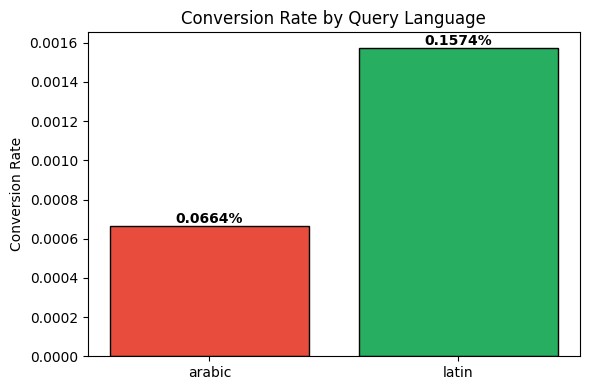

In [ ]:
# while arabic has the same average ctr as latin, it has 2.4x less conversions
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))

langs = ["arabic", "latin"]
conv = [arabic_conv, latin_conv]
colors = ["#e74c3c", "#27ae60"]

bars = ax.bar(langs, conv, color=colors, edgecolor="black")
ax.set_title("Conversion Rate by Query Language")
ax.set_ylabel("Conversion Rate")

for bar, v in zip(bars, conv):
    ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:.4%}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

In [50]:
search_df[["name", "designer", "class", "productclass"]].isnull().mean()

name            0.049483
designer        0.049490
class           0.049483
productclass    0.049490
dtype: float64

In [51]:
search_df.groupby(search_df["designer"].isnull()).agg(
    impressions=("plp_click", "count"),
    ctr=("plp_click", "mean"),
    conversion=("is_converted", "mean")
)
#note:
# 5% of product impressions have no catalog metadata and zero conversions 
# filtering these from the search index can lead to low-effort improvement to result quality.

,impressions,ctr,conversion
designer,,,
False,3910293,0.020124,0.00128
True,203598,0.019150,0.00000


# Question 1: Measuring Search Performance

We evaluate current search quality at the **query session level** (as defined above) using three metrics, broken down by keyword language.

| Metric | Definition | Rationale |
|--------|-----------|-----------|
| Success Rate | Fraction of query sessions with ≥1 click | Measures how often search returns anything worth exploring |
| MRR | Mean of 1/(first click position) | Measures how high in results the first relevant product appears |
| Conversion Rate | Fraction of query sessions with ≥1 purchase | Strongest signal of search-to-revenue effectiveness |

**Why MRR over nDCG?** Majority of successful queries have exactly one click so the first-click position captures nearly all ranking quality signal. nDCG adds minimal information given this distribution.

**Why language as the primary dimension?** The 40% Arabic / 60% Latin query split against a 95% Latin-script catalog is structurally consequential. Other dimensions (intent type, query length) are explored in Question 4.

### Findings

**Overall**: 68.7% of queries produce zero clicks. Among successful queries, MRR of ~0.15 means users typically scroll to position 6-7 before their first click. Both numbers indicate significant room for improvement in retrieval and ranking.

**Language segments reveal different failure modes:**
- **Arabic** has a higher success rate (33% vs 26.6%) but lower conversion (1.04% vs 1.89%). Users find things to click but what they click isn't precisely what they want. This means low precision.
- **Latin** has a lower success rate but higher conversion. Retrieval fails more often, but when it works, it works well, which makes it a retrieval coverage problem. 

**Implication for modeling**: Conversion is too sparse to serve as a modeling target (~1-2% of queries, within a single day of luxury e-commerce data). **Click is the primary behavioral signal** and will drive the modeling task in Part 2.

In [52]:
query_metrics = search_df.groupby(query_signature_final_cols + ["keyword_lang"]).agg(
    num_results=("product_id", "count"),
    num_clicks=("plp_click", "sum"),
    num_conversions=("is_converted", "sum"),
    first_click_position=("index", lambda x: x[search_df.loc[x.index, "plp_click"] == 1].min())
).reset_index()

query_metrics["reciprocal_rank"] = (1 / query_metrics["first_click_position"]).fillna(0)
mrr = query_metrics["reciprocal_rank"].mean()

In [ ]:
query_metrics.groupby("keyword_lang").agg(
    total_queries=("num_clicks", "count"),
    success_rate=("num_clicks", lambda x: (x > 0).mean()),
    mrr=("reciprocal_rank", "mean"),
    conversion_rate=("num_conversions", lambda x: (x > 0).mean())
).round(4)

,total_queries,success_rate,mrr,conversion_rate
keyword_type,,,,
arabic,90584,0.3300,0.0486,0.0104
latin,172692,0.2659,0.0437,0.0189
mixed,137,0.2774,0.1188,0.0219
other,189,0.3333,0.1711,0.0741


In [ ]:
# # MRR values interpretation: users are scrolling deep before finding something worth clicking

"""
hypothesis: different type of failure per language segment

Arabic: retrieval is working (users find things to click), but relevance precision is weak (what they click isn't what they want)

vs

Latin: retrieval itself may be failing more often (users don't find anything worth clicking), but when it works, it works well

"""

"""
Another primary take-away

conversion is too low to be meaningful in modelling (consider the context of luxury shopping + only a single day of data across ~4k unique queries)

Meaning, click rate is the primary modelling driver
"""

# Question 2: Identifying Problematic Queries

**How do we define poor search performance?** At the query level, poor performance manifests in two ways:

1. **Complete failure**: zero clicks. The system returned results but nothing was relevant enough to explore. This affects 68.7% of all queries.
2. **Ranking failure**: clicks occur but deep in the result list. Among successful queries, MRR of ~0.15 means users typically scroll to position 6-7 before finding a relevant product. A well-performing system should place the first relevant result in positions 2-3 (MRR ~0.3-0.5).

These map to different parts of the solution: **modeling (Part 2) addresses ranking failure**, while **system redesign (Part 3) addresses retrieval failure**.

### Approach
We examine both failing and succeeding keywords side by side. Many high-volume keywords appear on both lists (e.g., "Dress" has 1,771 failures and 1,218 successes), so raw failure count alone is misleading. We use **failure rate** (zero-click queries / total queries per keyword) to identify keywords that fail disproportionately relative to their volume.

### Three Failure Patterns

**Pattern 1: Arabic brand transliterations.** Keywords like غوتشي (Gucci, 69% failure), كوتش (Coach, 66%), سان لوران (Saint Laurent, 70%), توري بورش (Tory Burch, 64%). Users are searching for known brands in Arabic script. The keyword-based system cannot bridge the gap between Arabic queries and Latin-script catalog entries. These are high-intent navigational queries that should have high success rates: the failure is a retrieval problem.

**Pattern 2: Broad category queries.** "Evening gowns" (99.8% failure rate, 4,567 queries), "Perfume" (91%), "Watch" (90%), "White shirt" (91%). These are exploratory queries where the system retrieves products but fails to surface relevant ones. Both languages are affected. The failure here is ranking: the user gets results but nothing compelling enough to click.

**Pattern 3: Highly specific long-tail queries.** "Dolce & Gabbana D&G Slides in Rubber" (87% failure), "Charlotte Tilbury Pillow Talk" (100%). Users searching near-exact product descriptions. Keyword matching likely fragments on multi-token queries which dilutes precision. The use of semantic embeddings comes to mind here. 

### Supporting Finding
Keyword length is **not** a strong predictor of failure. Median length is similar across high-failure and low-failure groups (10 vs 12 characters). The failure modes are structural: language mismatch, catalog gaps, and ranking quality.

In [ ]:
# Zoning in on successful queries:

successful = query_metrics[query_metrics.num_clicks > 0]
successful.groupby("keyword_lang").agg(
    successful_queries=("reciprocal_rank", "count"),
    mrr_successful=("reciprocal_rank", "mean")
).round(4)

# first click typically lands around position 6-7. 
# a well-ranked system should have this closer to 0.3-0.5 (first click at position 2-3).

,successful_queries,mrr_successful
keyword_lang,,
arabic,29889,0.1474
latin,45920,0.1645
mixed,38,0.4285
other,63,0.5132


In [67]:
failure_df = search_df.groupby(["user_id","keyword","query_id","keyword_lang"]).plp_click.sum().reset_index()
failure_condition = failure_df.plp_click == 0 
failure_df = failure_df[failure_condition]

failure_df.groupby(["keyword", "keyword_lang"]).size().rename("keyword_failure_count")\
.reset_index().sort_values(by="keyword_failure_count",ascending=False)[:10]


,keyword,keyword_lang,keyword_failure_count
2906,Evening gowns,latin,4557
7588,Skims,latin,2911
6352,Perfume,latin,2347
15934,ناس,arabic,1835
2656,Dress,latin,1771
15240,كوتش,arabic,1516
784,Bag,latin,1376
8886,Watch,latin,1241
14335,فساتين,arabic,1203
5723,New balance,latin,1124


In [68]:
success_df = search_df.groupby(["user_id","keyword","query_id","keyword_lang"]).plp_click.sum().reset_index()
success_condition = success_df.plp_click > 0 
success_df = success_df[success_condition]

success_df.groupby(["keyword", "keyword_lang"]).size().rename("keyword_success_count")\
.reset_index().sort_values(by="keyword_success_count",ascending=False)[:10]


,keyword,keyword_lang,keyword_success_count
1442,Dress,latin,1218
4240,Skims,latin,1180
7973,فساتين سهره,arabic,1165
7931,فساتين,arabic,1140
8789,ناس,arabic,1011
8414,كوتش,arabic,794
118,Abaya,latin,785
8017,فستان,arabic,583
8103,فستان سهرة,arabic,536
1140,Coach,latin,504


In [59]:
keyword_perf = query_metrics.groupby(["keyword", "keyword_lang"]).agg(
    total_queries=("num_clicks", "count"),
    zero_click=("num_clicks", lambda x: (x == 0).sum()),
    total_clicks=("num_clicks", "sum"),
).reset_index()

keyword_perf["keyword_length"] = keyword_perf["keyword"].str.len()
keyword_perf["failure_rate"] = keyword_perf["zero_click"] / keyword_perf["total_queries"]


In [70]:
# High volume queries that fail
keyword_perf.sort_values(["total_queries","failure_rate"], ascending=False)[:50]

,keyword,keyword_lang,total_queries,zero_click,total_clicks,keyword_length,failure_rate
2907,Evening gowns,latin,4567,4557,10,13,0.997810
7590,Skims,latin,4091,2911,1273,5,0.711562
2657,Dress,latin,2989,1771,1371,5,0.592506
15936,ناس,arabic,2846,1835,1139,3,0.644765
6354,Perfume,latin,2578,2347,244,7,0.910396
14337,فساتين,arabic,2343,1203,1299,6,0.513444
15242,كوتش,arabic,2310,1516,844,4,0.656277
14407,فساتين سهره,arabic,2132,967,1348,11,0.453565
784,Bag,latin,1796,1376,447,3,0.766147
218,Abaya,latin,1649,864,876,5,0.523954


Low failure (<0.2): {'count': 17.0, 'mean': 13.4, 'std': 7.1, 'min': 2.0, '25%': 10.0, '50%': 12.0, '75%': 15.0, 'max': 35.0}
High failure (>0.8): {'count': 8653.0, 'mean': 10.4, 'std': 5.1, 'min': 1.0, '25%': 7.0, '50%': 10.0, '75%': 13.0, 'max': 48.0}


/var/folders/8l/vy79x4r97dn8s56m1p40s5lw0000gn/T/ipykernel_3781/1004207178.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([low_fail, high_fail], labels=["Failure < 20%", "Failure > 80%"])


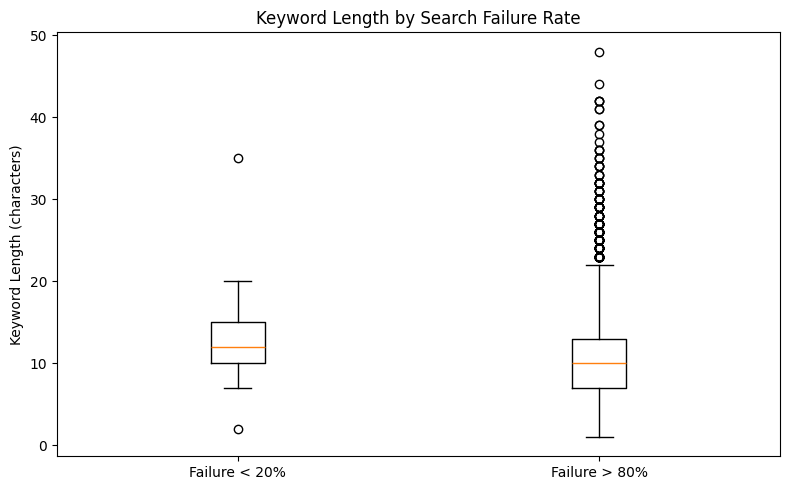

In [63]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

low_fail = keyword_perf[keyword_perf.failure_rate < 0.2]["keyword_length"]
high_fail = keyword_perf[keyword_perf.failure_rate > 0.8]["keyword_length"]

ax.boxplot([low_fail, high_fail], labels=["Failure < 20%", "Failure > 80%"])
ax.set_ylabel("Keyword Length (characters)")
ax.set_title("Keyword Length by Search Failure Rate")

print("Low failure (<0.2):", low_fail.describe().round(1).to_dict())
print("High failure (>0.8):", high_fail.describe().round(1).to_dict())

plt.tight_layout()
plt.show()

In [65]:
keyword_perf[(keyword_perf.failure_rate > 0.8) & (keyword_perf.keyword_length > 30)].sort_values("total_queries", ascending=False).head(10)[["keyword", "keyword_lang", "total_queries", "failure_rate"]]


,keyword,keyword_lang,total_queries,failure_rate
2578,Dolce & Gabbana D&G Slides in Rubber,latin,31,0.870968
1908,Charlotte tilbury flawless filter,latin,13,0.923077
16223,•\tCharlotte Tilbury Pillow Talk,latin,11,1.000000
12707,حقيبة كتف سوينجر 20 جاكار بشعار الماركة,arabic,7,0.857143
8240,The Ordinary Hyaluronic Acid 2% + B5,latin,7,0.857143
5121,Maria lucia hohan jolie midi dress,latin,7,0.857143
5632,NIKE Dunk Low Sneakers in Leather & Suede,latin,6,0.833333
350,Afternoon dress long sleeve dress,latin,6,1.000000
2806,Elisabetta franchi black shirt,latin,6,1.000000
3021,Fear of God Essentials in shorts,latin,5,1.000000


# Question 3: Position Bias

**Observation:** CTR decays sharply with position. Products at index 1 are clicked at ~7.5% vs ~2% beyond position 20. Among viewed products, position alone accounts for a ~3.5x difference in click probability.

**Why this matters:** Position confounds our click signal. Users click early results disproportionately, not necessarily because they are more relevant, but because they are seen first. If we train a click model on this data naively, it learns to replicate the existing ranking rather than improve it.

**Correction approach:** Include `index` as a feature during model training so the model can separate the position effect from product relevance. At inference time, set position to a constant across all candidates. This neutralizes the bias and ranks purely by learned relevance.

**Alternative considered:** Inverse propensity weighting (upweighting clicks at lower positions as stronger relevance signals) is more principled but introduces additional estimation complexity. The position-as-feature approach aims to achieve the same debiasing with fewer assumptions. In a professional setting, I would be inclined to experiment with both approaches and evalute results accordingly.

**Evaluation implication:** To validate the model, we compare its re-ranked ordering against the original ranking on held-out queries. If products that were actually clicked or converted move higher in the model's ranking, the debiasing is working.

<Axes: xlabel='index'>

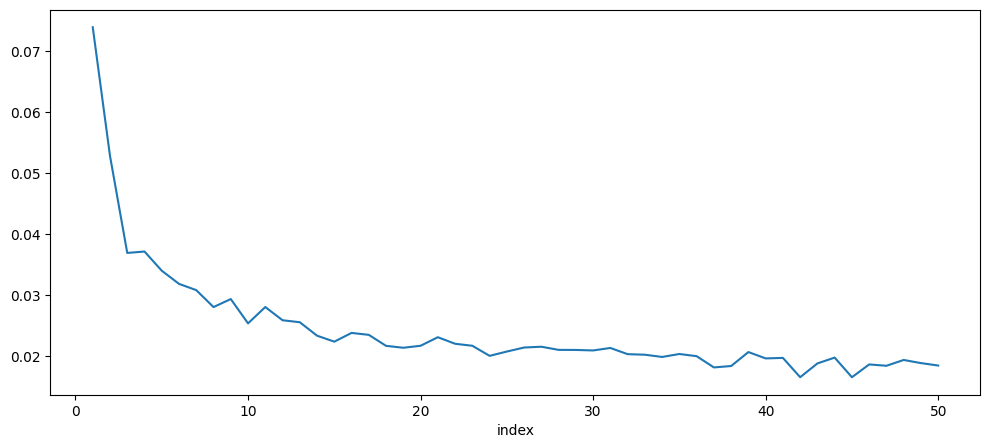

In [91]:
#among products the user actually saw, what fraction did they click? 

position_ctr = search_df.groupby("index").agg(
    views=("plp_view", "sum"),
    clicks=("plp_click", "sum")
)
position_ctr["ctr"] = position_ctr["clicks"] / position_ctr["views"]
position_ctr["ctr"].iloc[:50].plot(figsize=(12, 5))

In [92]:
position_ctr[:20]

,views,clicks,ctr
index,,,
1,81554,6024,0.073865
2,79774,4213,0.052812
3,76352,2820,0.036934
4,70127,2606,0.037161
5,52406,1783,0.034023
6,51617,1645,0.031869
7,48700,1502,0.030842
8,48340,1357,0.028072
9,46213,1358,0.029386


# Question 4: Intent Segmentation

**Approach:** We classify queries into two intent types using substring matching against known designer names from the catalog:

- **Navigational**: keyword contains a known brand/designer name. The user knows what they want ("Gucci," "Coach bag," "New Balance").
- **Exploratory**: keyword does not match any designer. The user is browsing a category ("Evening gowns," "Shoes," "فساتين").

This is a conservative heuristic. Arabic brand transliterations (غوتشي for Gucci, كوتش for Coach) are not captured because they cannot match against Latin-script designer names. The navigational bucket is therefore undercounted, which means its true performance is likely even stronger than reported.

### Findings

| | Queries | Success Rate | MRR | Conversion |
|---|---|---|---|---|
| Exploratory | 203,547 | 29.3% | 0.042 | 1.32% |
| Navigational | 60,055 | 27.2% | 0.057 | 2.55% |

**Navigational queries click less often but convert at ~2x the rate.** Users with brand intent are harder to engage (lower success rate) but far more likely to buy when they do find what they want. MRR is also higher (0.057 vs 0.042), meaning relevant results surface closer to the top for brand queries.

**Implication for search design:** These intents warrant different ranking strategies. Navigational queries should prioritize retrieval precision within the target brand. Exploratory queries should prioritize curation across brands, leveraging popularity, recency, or collaborative signals.

In [88]:
known_designers = set(search_df["designer"].dropna().str.lower().unique())

In [89]:
query_metrics["intent"] = query_metrics["keyword"].str.lower().apply(
    lambda x: "navigational" if any(d in x for d in known_designers) else "exploratory"
)

query_metrics.groupby("intent").agg(
    queries=("num_clicks", "count"),
    success_rate=("num_clicks", lambda x: (x > 0).mean()),
    mrr=("reciprocal_rank", "mean"),
    conversion=("num_conversions", lambda x: (x > 0).mean())
)

,queries,success_rate,mrr,conversion
intent,,,,
exploratory,203547,0.292655,0.042071,0.013186
navigational,60055,0.272101,0.057368,0.025527


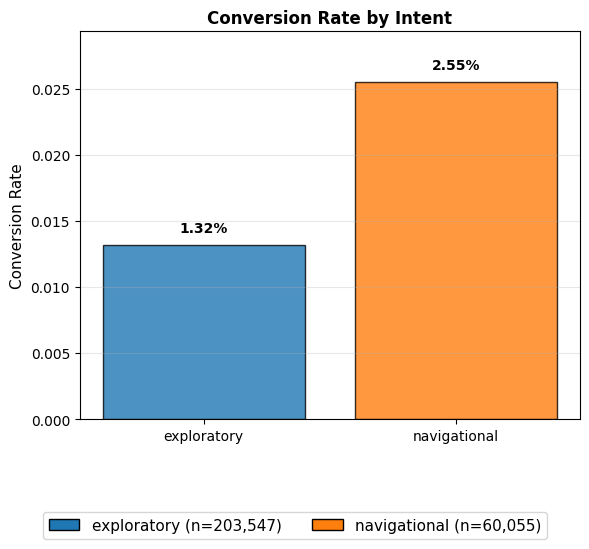

In [90]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

intent_metrics = query_metrics.groupby("intent").agg(
    queries=("num_clicks", "count"),
    success_rate=("num_clicks", lambda x: (x > 0).mean()),
    mrr=("reciprocal_rank", "mean"),
    conversion=("num_conversions", lambda x: (x > 0).mean())
).reset_index()

intents = intent_metrics["intent"].values
colors = ["#1f77b4", "#ff7f0e"]

fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(intents, intent_metrics["conversion"], color=colors, alpha=0.8, edgecolor='black')
ax.set_title("Conversion Rate by Intent", fontsize=12, fontweight='bold')
ax.set_ylabel("Conversion Rate", fontsize=11)
ax.set_ylim(0, max(intent_metrics["conversion"]) * 1.15)
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(intent_metrics["conversion"]):
    ax.text(i, v + 0.001, f'{v:.2%}', ha='center', fontweight='bold')

legend_labels = [f"{intent} (n={int(q):,})" for intent, q in zip(intents, intent_metrics["queries"])]
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', label=legend_labels[i]) for i in range(len(intents))]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.02), fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()